# Дипломная работа: Детекция переутомления спортсмена
## 1D CNN модель на данных носимых датчиков

**Цель:** Разработка системы автоматического определения переутомления спортсмена

**Датасеты:**
- Zenodo Running IMU (19 субъектов) — бег 400м до/после Beep Test
- 4TU Marotta (8 субъектов) — бег 4км + протокол утомления до RPE>16

**Данные:** Шаги (strides), 100 точек × 6 каналов (ax, ay, az, gx, gy, gz)

**Модель:** 1D Convolutional Neural Network (~175K параметров)

In [1]:
# Импорт библиотек
import os
import sys
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    f1_score, roc_auc_score, balanced_accuracy_score, 
    confusion_matrix, classification_report, precision_recall_curve, auc
)

# Добавляем путь к модулю afc
sys.path.insert(0, str(Path.cwd().parent))
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

# Настройки визуализации
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

PyTorch version: 2.10.0+cpu
CUDA available: False
Using device: cpu


## 2. Загрузка и исследование данных

Загружаем композиционный датасет из `data/processed/composite_strides.npz`:
- `X`: массив шагов (N_strides × 100 точек × 6 каналов)
- `y`: метки (0=норма, 1=усталость)
- `pids`: ID субъектов (формат: "zenodo_X" или "4tu_X")
- `domains`: источник данных ("zenodo" или "4tu")
- `channels`: список каналов (ax, ay, az, gx, gy, gz)

In [2]:
# Надёжное определение корня проекта
def find_project_root(marker='config.yaml', start=None, max_levels=5):
    """Ищет корень проекта по файлу-маркеру, поднимаясь вверх по дереву."""
    current = Path(start or os.getcwd()).resolve()
    for _ in range(max_levels):
        if (current / marker).exists():
            return current
        if current.parent == current:
            break
        current = current.parent
    raise FileNotFoundError(
        f"Не найден маркер '{marker}'. CWD={os.getcwd()}. "
        f"Убедитесь, что ноутбук запущен из директории проекта."
    )

PROJECT_ROOT = find_project_root('config.yaml')
DATA_FILE = PROJECT_ROOT / 'data' / 'processed' / 'composite_strides.npz'
RESULTS_DIR = (PROJECT_ROOT / 'results').resolve()
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Data file:    {DATA_FILE} (exists={DATA_FILE.exists()})")

Project root: D:\Github\afc_lab
Data file:    D:\Github\afc_lab\data\processed\composite_strides.npz (exists=True)


In [3]:
# Загрузка композиционного датасета
print(f"Загрузка данных из {DATA_FILE}...")

data = np.load(DATA_FILE, allow_pickle=True)

X_all = data['X'].astype(np.float32)  # (N, 100, 6)
y_all = data['y'].astype(np.int64)     # (N,)
subjects = data['pids']                 # (N,) - строки "zenodo_1", "4tu_1", ...
domains = data['domains']               # (N,) - "zenodo" или "4tu"
channels = data['channels']             # ['ax', 'ay', 'az', 'gx', 'gy', 'gz']

print(f"\n✅ Данные загружены:")
print(f"   X shape: {X_all.shape}")
print(f"   y shape: {y_all.shape}")
print(f"   Каналы: {list(channels)}")
print(f"   Субъектов: {len(np.unique(subjects))}")
print(f"   Доменов: {list(np.unique(domains))}")

Загрузка данных из D:\Github\afc_lab\data\processed\composite_strides.npz...

✅ Данные загружены:
   X shape: (24868, 100, 6)
   y shape: (24868,)
   Каналы: [np.str_('ax'), np.str_('ay'), np.str_('az'), np.str_('gx'), np.str_('gy'), np.str_('gz')]
   Субъектов: 27
   Доменов: [np.str_('4tu'), np.str_('zenodo')]


In [4]:
# Анализ распределения данных
df_meta = pd.DataFrame({
    'sid': subjects,
    'domain': domains,
    'y': y_all,
})

print("=" * 60)
print("СТАТИСТИКА ДАТАСЕТА")
print("=" * 60)

# Распределение по доменам
print("\n📊 Распределение по источникам данных:")
print(df_meta['domain'].value_counts())

# Распределение по классам
print("\n📊 Распределение по классам (0=норма, 1=усталость):")
print(df_meta['y'].value_counts())
print(f"\nБаланс классов: {df_meta['y'].mean():.2%} положительных")

# Количество субъектов
print(f"\n👥 Уникальных субъектов: {df_meta['sid'].nunique()}")
print("По доменам:")
for domain in df_meta['domain'].unique():
    n_subj = df_meta[df_meta['domain'] == domain]['sid'].nunique()
    print(f"  - {domain}: {n_subj} субъектов")

СТАТИСТИКА ДАТАСЕТА

📊 Распределение по источникам данных:
domain
4tu       18862
zenodo     6006
Name: count, dtype: int64

📊 Распределение по классам (0=норма, 1=усталость):
y
1    12512
0    12356
Name: count, dtype: int64

Баланс классов: 50.31% положительных

👥 Уникальных субъектов: 27
По доменам:
  - zenodo: 19 субъектов
  - 4tu: 8 субъектов


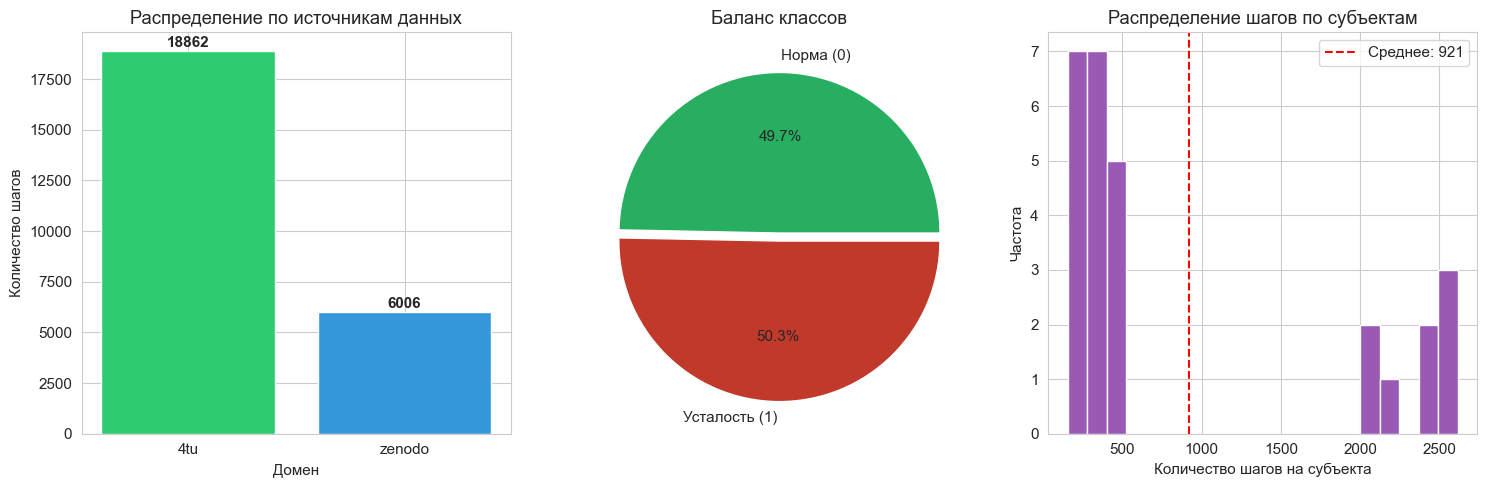

In [5]:
# Визуализация распределений
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Распределение по доменам
domain_counts = df_meta['domain'].value_counts()
axes[0].bar(domain_counts.index, domain_counts.values, color=['#2ecc71', '#3498db'])
axes[0].set_title('Распределение по источникам данных')
axes[0].set_xlabel('Домен')
axes[0].set_ylabel('Количество шагов')
for i, v in enumerate(domain_counts.values):
    axes[0].text(i, v + 200, str(v), ha='center', fontweight='bold')

# 2. Распределение по классам
class_counts = df_meta['y'].value_counts().sort_index()
colors = ['#27ae60', '#c0392b']
axes[1].pie(class_counts.values, labels=['Норма (0)', 'Усталость (1)'], 
            autopct='%1.1f%%', colors=colors, explode=[0, 0.05])
axes[1].set_title('Баланс классов')

# 3. Распределение шагов по субъектам
subj_counts = df_meta.groupby('sid').size()
axes[2].hist(subj_counts, bins=20, color='#9b59b6', edgecolor='white')
axes[2].set_title('Распределение шагов по субъектам')
axes[2].set_xlabel('Количество шагов на субъекта')
axes[2].set_ylabel('Частота')
axes[2].axvline(subj_counts.mean(), color='red', linestyle='--', label=f'Среднее: {subj_counts.mean():.0f}')
axes[2].legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'data_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

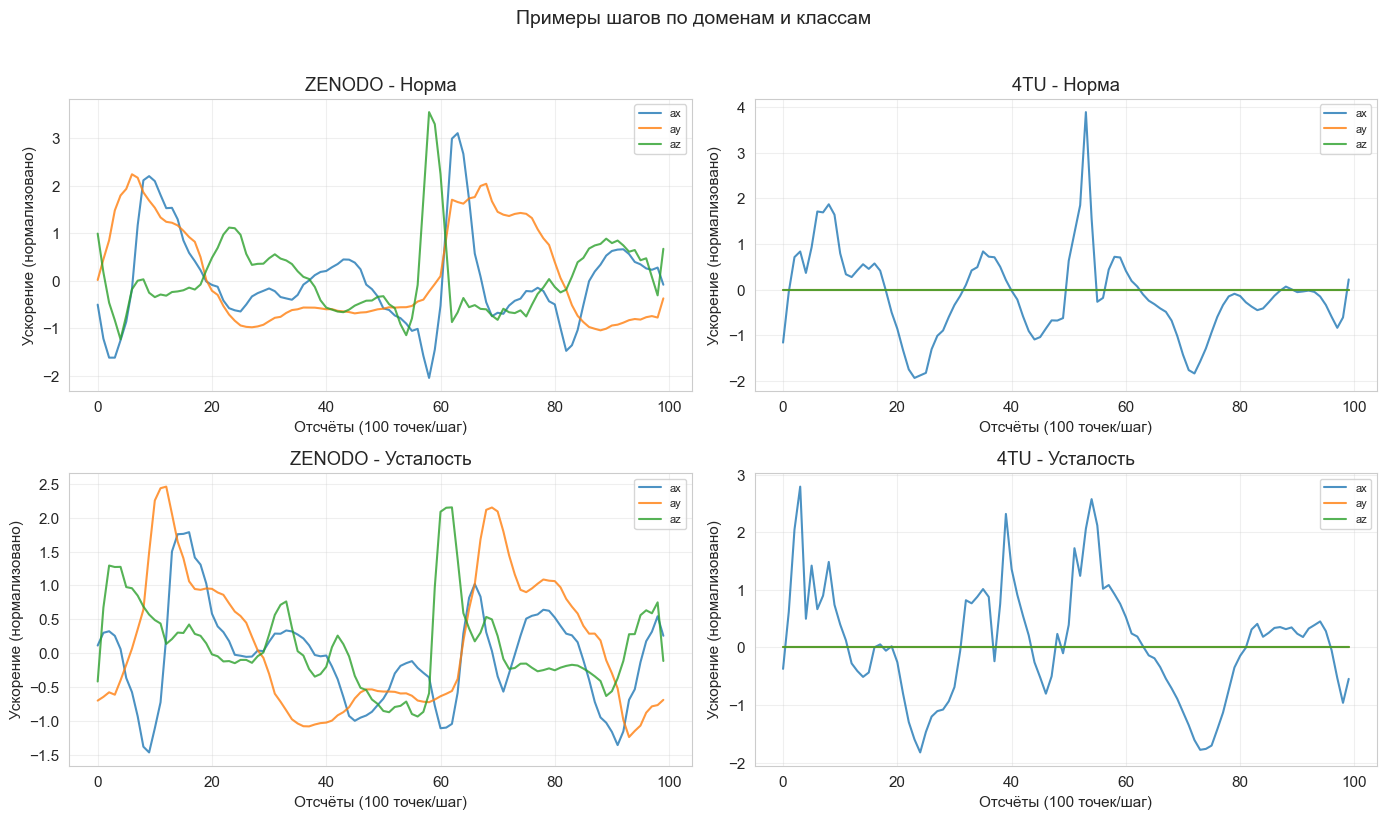

In [6]:
# Визуализация примеров шагов (strides)
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Находим примеры для каждого домена и класса
for col, domain in enumerate(['zenodo', '4tu']):
    domain_mask = domains == domain
    
    for row, label in enumerate([0, 1]):
        label_mask = y_all == label
        combined_mask = domain_mask & label_mask
        indices = np.where(combined_mask)[0]
        
        if len(indices) > 0:
            idx = indices[0]
            X = X_all[idx]  # (100, 6)
            
            ax = axes[row, col]
            time_axis = np.arange(X.shape[0])  # 100 точек
            
            # Отображаем все 6 каналов
            for ch in range(3):  # ax, ay, az
                ax.plot(time_axis, X[:, ch], label=f'a{["x", "y", "z"][ch]}', alpha=0.8)
            
            status = 'Усталость' if label == 1 else 'Норма'
            ax.set_title(f'{domain.upper()} - {status}')
            ax.set_xlabel('Отсчёты (100 точек/шаг)')
            ax.set_ylabel('Ускорение (нормализовано)')
            ax.legend(loc='upper right', fontsize=8)
            ax.grid(True, alpha=0.3)

plt.suptitle('Примеры шагов по доменам и классам', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'signal_examples.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Подготовка данных для обучения

### 3.1 Формирование фолдов

Используем два подхода к валидации:
1. **LOSO (Leave-One-Subject-Out)** - для оценки обобщающей способности
2. **Train/Val/Test Split** - для быстрого прототипирования

### 3.2 Данные

Данные уже нормализованы (Z-score по субъектам) при сборке датасета:
- Размер шага: 100 точек
- Количество каналов: 6 (ax, ay, az, gx, gy, gz)

In [7]:
# Конфигурация данных (уже подготовлены при сборке)
TARGET_CHANNELS = 6   # ax, ay, az, gx, gy, gz
TARGET_SAMPLES = 100  # 100 точек на шаг

print(f"✅ Данные уже подготовлены:")
print(f"   X shape: {X_all.shape}")
print(f"   y shape: {y_all.shape}")
print(f"   Субъектов: {len(np.unique(subjects))}")
print(f"   Доменов: {len(np.unique(domains))}")
print(f"   NaN значений: {np.isnan(X_all).sum()}")
print(f"   X min: {X_all.min():.3f}, max: {X_all.max():.3f}")

✅ Данные уже подготовлены:
   X shape: (24868, 100, 6)
   y shape: (24868,)
   Субъектов: 27
   Доменов: 2
   NaN значений: 0
   X min: -12.247, max: 17.095


In [8]:
# Создание фолдов для LOSO
def create_loso_folds(subjects):
    """Создание фолдов для Leave-One-Subject-Out."""
    unique_subjects = np.unique(subjects)
    folds = []
    
    for test_subject in unique_subjects:
        train_mask = subjects != test_subject
        test_mask = subjects == test_subject
        folds.append({
            'train_idx': np.where(train_mask)[0],
            'test_idx': np.where(test_mask)[0],
            'test_subject': test_subject
        })
    
    return folds

# Создание train/val/test split по субъектам
def create_subject_split(subjects, test_size=0.2, val_size=0.1, random_state=42):
    """Разбиение по субъектам (не по окнам)."""
    unique_subjects = np.unique(subjects)
    np.random.seed(random_state)
    np.random.shuffle(unique_subjects)
    
    n = len(unique_subjects)
    n_test = int(n * test_size)
    n_val = int(n * val_size)
    
    test_subjects = set(unique_subjects[:n_test])
    val_subjects = set(unique_subjects[n_test:n_test + n_val])
    train_subjects = set(unique_subjects[n_test + n_val:])
    
    train_idx = np.array([i for i, s in enumerate(subjects) if s in train_subjects])
    val_idx = np.array([i for i, s in enumerate(subjects) if s in val_subjects])
    test_idx = np.array([i for i, s in enumerate(subjects) if s in test_subjects])
    
    return train_idx, val_idx, test_idx

# Создаём split
train_idx, val_idx, test_idx = create_subject_split(subjects)
print(f"Train: {len(train_idx)} окон ({len(train_idx)/len(y_all)*100:.1f}%)")
print(f"Val:   {len(val_idx)} окон ({len(val_idx)/len(y_all)*100:.1f}%)")
print(f"Test:  {len(test_idx)} окон ({len(test_idx)/len(y_all)*100:.1f}%)")

# Баланс классов в каждом split
for name, idx in [('Train', train_idx), ('Val', val_idx), ('Test', test_idx)]:
    pos_ratio = y_all[idx].mean()
    print(f"  {name}: {pos_ratio:.1%} положительных")

Train: 21173 окон (85.1%)
Val:   476 окон (1.9%)
Test:  3219 окон (12.9%)
  Train: 50.0% положительных
  Val: 60.7% положительных
  Test: 51.1% положительных


## 4. Архитектура модели 1D CNN

### Структура сети FatigueCNN1D:

```
Input (batch, 100, 6) → transpose → (batch, 6, 100)
    ↓
Conv1D Block 1: Conv(6→64, k=7) → BN → ReLU → MaxPool → Dropout
    ↓
Conv1D Block 2: Conv(64→128, k=5) → BN → ReLU → MaxPool → Dropout
    ↓
Conv1D Block 3: Conv(128→256, k=3) → BN → ReLU → AdaptiveAvgPool
    ↓
Classifier: Flatten → Linear(256→128) → ReLU → Dropout → Linear(128→1) → Sigmoid
    ↓
Output: probability [0, 1]
```

**Всего параметров:** ~175K (легковесная модель для носимых устройств)

In [9]:
# PyTorch Dataset
class FatigueDataset(Dataset):
    """Dataset для данных переутомления."""
    
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)
    
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# 1D CNN Модель
class FatigueCNN1D(nn.Module):
    """
    1D CNN для детекции переутомления.
    
    Архитектура: 3 свёрточных блока + классификатор
    Вход: (batch, time_steps, channels) = (batch, 30, 6)
    Выход: (batch,) - вероятность переутомления
    """
    
    def __init__(self, in_channels=6, dropout=0.2):
        super().__init__()
        
        # Блок 1: низкоуровневые паттерны
        self.conv1 = nn.Sequential(
            nn.Conv1d(in_channels, 64, kernel_size=7, stride=1, padding=3),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2, stride=2),
            nn.Dropout(dropout)
        )
        
        # Блок 2: среднеуровневые паттерны  
        self.conv2 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2, stride=2),
            nn.Dropout(dropout)
        )
        
        # Блок 3: высокоуровневые паттерны
        self.conv3 = nn.Sequential(
            nn.Conv1d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool1d(1)  # Global Average Pooling
        )
        
        # Классификатор
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(128, 1)
        )
    
    def forward(self, x):
        # x: (batch, time, channels) -> (batch, channels, time)
        x = x.transpose(1, 2)
        
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        
        logits = self.classifier(x)
        return logits.squeeze(-1)
    
    def predict_proba(self, x):
        """Возвращает вероятности."""
        with torch.no_grad():
            logits = self.forward(x)
            return torch.sigmoid(logits)

# Создаём модель и выводим информацию
model = FatigueCNN1D(in_channels=TARGET_CHANNELS).to(DEVICE)

# Подсчёт параметров
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("=" * 60)
print("АРХИТЕКТУРА МОДЕЛИ")
print("=" * 60)
print(model)
print(f"\n📊 Всего параметров: {total_params:,}")
print(f"📊 Обучаемых параметров: {trainable_params:,}")

АРХИТЕКТУРА МОДЕЛИ
FatigueCNN1D(
  (conv1): Sequential(
    (0): Conv1d(6, 64, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.2, inplace=False)
  )
  (conv2): Sequential(
    (0): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.2, inplace=False)
  )
  (conv3): Sequential(
    (0): Conv1d(128, 256, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): AdaptiveAvgPool1d(output_size=1)
  )
  (classifier): Sequential(
    (0):

## 5. Обучение модели

### Конфигурация обучения:
- **Оптимизатор:** AdamW (weight_decay=1e-4)
- **Learning Rate:** 0.001 с Cosine Annealing
- **Loss:** BCEWithLogitsLoss с весами классов
- **Batch Size:** 64
- **Epochs:** 50 (с Early Stopping, patience=10)

In [10]:
# Конфигурация обучения
CONFIG = {
    'batch_size': 64,
    'epochs': 50,
    'lr': 0.001,
    'weight_decay': 1e-4,
    'patience': 10,
    'min_delta': 1e-4
}

def compute_class_weights(y):
    """Вычисление весов классов для несбалансированных данных."""
    n_samples = len(y)
    n_pos = y.sum()
    n_neg = n_samples - n_pos
    
    if n_pos == 0 or n_neg == 0:
        return 1.0
    
    weight = n_neg / n_pos
    return weight

class EarlyStopping:
    """Early stopping для предотвращения переобучения."""
    
    def __init__(self, patience=10, min_delta=1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = float('inf')
        self.counter = 0
        self.best_model = None
    
    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            self.best_model = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            return False
        
        self.counter += 1
        return self.counter >= self.patience

def train_epoch(model, loader, optimizer, criterion, device):
    """Обучение одной эпохи."""
    model.train()
    total_loss = 0
    
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        
        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        total_loss += loss.item() * len(y_batch)
    
    return total_loss / len(loader.dataset)

def validate(model, loader, criterion, device):
    """Валидация модели."""
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            total_loss += loss.item() * len(y_batch)
            
            probs = torch.sigmoid(logits)
            all_preds.extend(probs.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
    
    avg_loss = total_loss / len(loader.dataset)
    
    # Метрики
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    y_pred_binary = (all_preds >= 0.5).astype(int)
    
    f1 = f1_score(all_labels, y_pred_binary, average='macro')
    
    try:
        roc_auc = roc_auc_score(all_labels, all_preds)
    except:
        roc_auc = 0.5
    
    return avg_loss, f1, roc_auc

print("✅ Функции обучения определены")

✅ Функции обучения определены


In [11]:
# Подготовка данных для обучения
train_dataset = FatigueDataset(X_all[train_idx], y_all[train_idx])
val_dataset = FatigueDataset(X_all[val_idx], y_all[val_idx])
test_dataset = FatigueDataset(X_all[test_idx], y_all[test_idx])

train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=CONFIG['batch_size'], shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=CONFIG['batch_size'], shuffle=False, num_workers=0)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

# Инициализация модели
model = FatigueCNN1D(in_channels=TARGET_CHANNELS).to(DEVICE)

# Веса классов
pos_weight = compute_class_weights(y_all[train_idx])
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight]).to(DEVICE))
print(f"\nВес положительного класса: {pos_weight:.2f}")

# Оптимизатор
optimizer = optim.AdamW(model.parameters(), lr=CONFIG['lr'], weight_decay=CONFIG['weight_decay'])

# Scheduler
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG['epochs'], eta_min=1e-6)

# Early Stopping
early_stopping = EarlyStopping(patience=CONFIG['patience'])

Train batches: 331
Val batches: 8
Test batches: 51

Вес положительного класса: 1.00


In [12]:
# Обучение модели
print("=" * 60)
print("НАЧАЛО ОБУЧЕНИЯ")
print("=" * 60)

history = {
    'train_loss': [],
    'val_loss': [],
    'val_f1': [],
    'val_auc': [],
    'lr': []
}

best_val_f1 = 0
best_epoch = 0

for epoch in range(CONFIG['epochs']):
    # Train
    train_loss = train_epoch(model, train_loader, optimizer, criterion, DEVICE)
    
    # Validate
    val_loss, val_f1, val_auc = validate(model, val_loader, criterion, DEVICE)
    
    # Scheduler step
    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]
    
    # Save history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_f1'].append(val_f1)
    history['val_auc'].append(val_auc)
    history['lr'].append(current_lr)
    
    # Track best
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_epoch = epoch + 1
        torch.save(model.state_dict(), RESULTS_DIR / 'best_model.pth')
    
    # Print progress
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:3d}/{CONFIG['epochs']} | "
              f"Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | "
              f"Val F1: {val_f1:.4f} | "
              f"Val AUC: {val_auc:.4f} | "
              f"LR: {current_lr:.6f}")
    
    # Early stopping
    if early_stopping(val_loss, model):
        print(f"\n⚡ Early stopping at epoch {epoch + 1}")
        break

print(f"\n✅ Обучение завершено!")
print(f"   Лучшая эпоха: {best_epoch}")
print(f"   Лучший Val F1: {best_val_f1:.4f}")

НАЧАЛО ОБУЧЕНИЯ
Epoch   1/50 | Train Loss: 0.4407 | Val Loss: 2.3348 | Val F1: 0.3508 | Val AUC: 0.7048 | LR: 0.000999
Epoch   5/50 | Train Loss: 0.2523 | Val Loss: 1.5647 | Val F1: 0.5485 | Val AUC: 0.7067 | LR: 0.000976
Epoch  10/50 | Train Loss: 0.2096 | Val Loss: 2.1637 | Val F1: 0.5276 | Val AUC: 0.5408 | LR: 0.000905
Epoch  15/50 | Train Loss: 0.1883 | Val Loss: 2.5955 | Val F1: 0.5348 | Val AUC: 0.5931 | LR: 0.000794

⚡ Early stopping at epoch 15

✅ Обучение завершено!
   Лучшая эпоха: 14
   Лучший Val F1: 0.5541


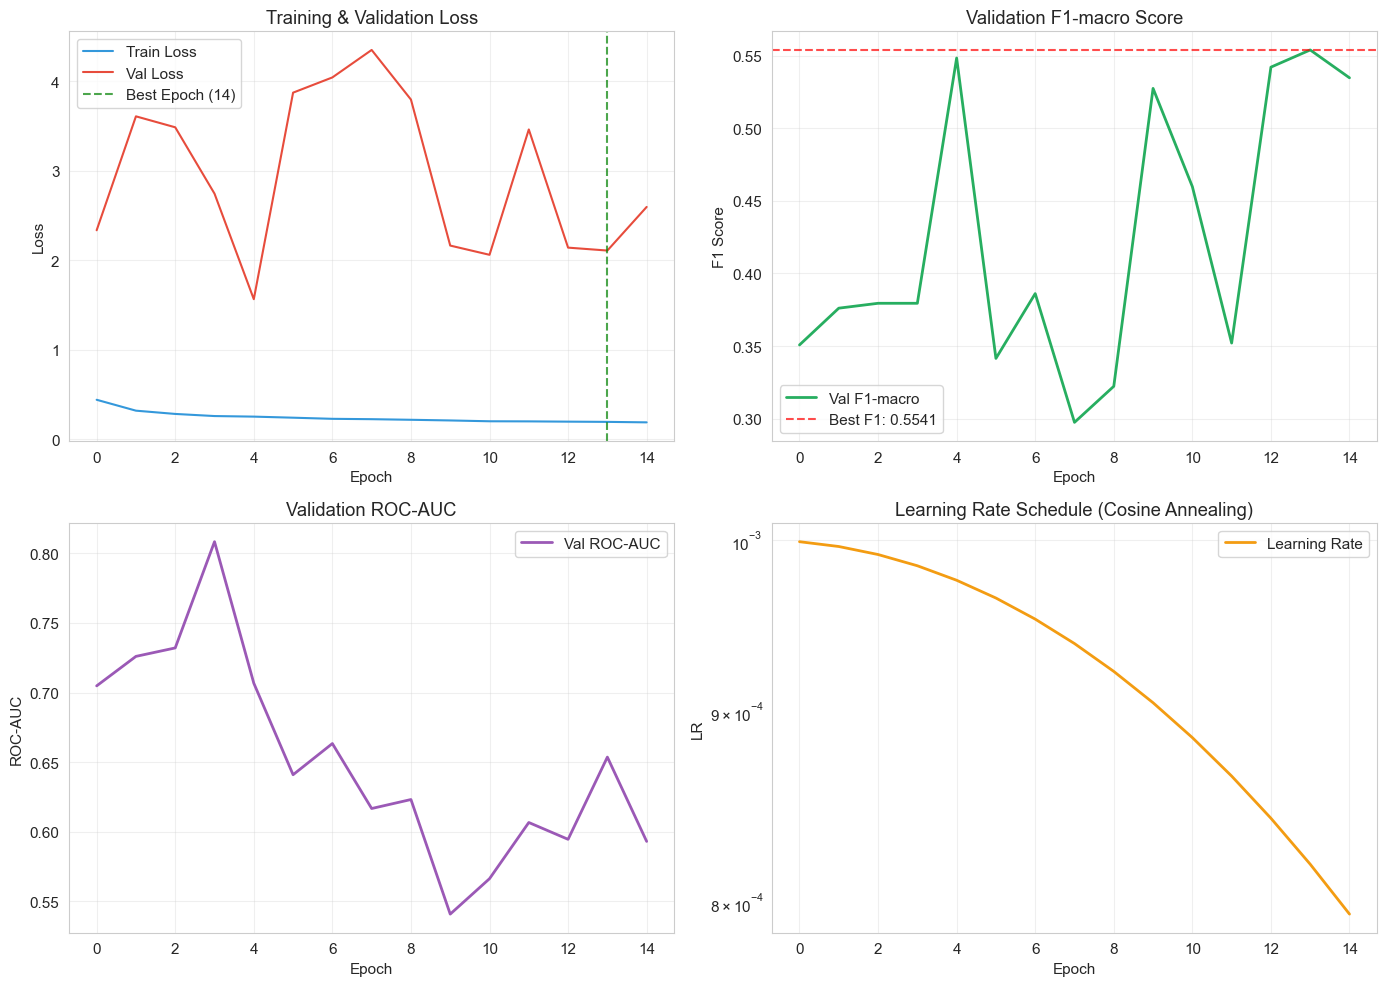

In [13]:
# Визуализация истории обучения
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Loss
ax = axes[0, 0]
ax.plot(history['train_loss'], label='Train Loss', color='#3498db')
ax.plot(history['val_loss'], label='Val Loss', color='#e74c3c')
ax.axvline(best_epoch - 1, color='green', linestyle='--', alpha=0.7, label=f'Best Epoch ({best_epoch})')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training & Validation Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. F1 Score
ax = axes[0, 1]
ax.plot(history['val_f1'], label='Val F1-macro', color='#27ae60', linewidth=2)
ax.axhline(best_val_f1, color='red', linestyle='--', alpha=0.7, label=f'Best F1: {best_val_f1:.4f}')
ax.set_xlabel('Epoch')
ax.set_ylabel('F1 Score')
ax.set_title('Validation F1-macro Score')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. ROC-AUC
ax = axes[1, 0]
ax.plot(history['val_auc'], label='Val ROC-AUC', color='#9b59b6', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('ROC-AUC')
ax.set_title('Validation ROC-AUC')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Learning Rate
ax = axes[1, 1]
ax.plot(history['lr'], label='Learning Rate', color='#f39c12', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('LR')
ax.set_title('Learning Rate Schedule (Cosine Annealing)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'training_history.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Оценка модели на тестовых данных

Загружаем лучшую модель и оцениваем на тестовой выборке:
- Confusion Matrix
- Classification Report
- ROC Curve
- Precision-Recall Curve

In [14]:
# Загрузка лучшей модели
model.load_state_dict(torch.load(RESULTS_DIR / 'best_model.pth', weights_only=True))
model.eval()

# Предсказания на тестовой выборке
all_preds = []
all_probs = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        
        logits = model(X_batch)
        probs = torch.sigmoid(logits)
        
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend((probs >= 0.5).cpu().numpy().astype(int))
        all_labels.extend(y_batch.numpy())

all_probs = np.array(all_probs)
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Метрики
print("=" * 60)
print("РЕЗУЛЬТАТЫ НА ТЕСТОВОЙ ВЫБОРКЕ")
print("=" * 60)

f1_macro = f1_score(all_labels, all_preds, average='macro')
f1_weighted = f1_score(all_labels, all_preds, average='weighted')
bal_acc = balanced_accuracy_score(all_labels, all_preds)

try:
    roc_auc = roc_auc_score(all_labels, all_probs)
except:
    roc_auc = 0.5

try:
    precision_vals, recall_vals, _ = precision_recall_curve(all_labels, all_probs)
    pr_auc = auc(recall_vals, precision_vals)
except:
    pr_auc = 0.5

print(f"\n📊 Метрики:")
print(f"   F1-macro:          {f1_macro:.4f}")
print(f"   F1-weighted:       {f1_weighted:.4f}")
print(f"   Balanced Accuracy: {bal_acc:.4f}")
print(f"   ROC-AUC:           {roc_auc:.4f}")
print(f"   PR-AUC:            {pr_auc:.4f}")

print("\n📋 Classification Report:")
print(classification_report(all_labels, all_preds, 
                           target_names=['Норма (0)', 'Усталость (1)']))

РЕЗУЛЬТАТЫ НА ТЕСТОВОЙ ВЫБОРКЕ

📊 Метрики:
   F1-macro:          0.7259
   F1-weighted:       0.7251
   Balanced Accuracy: 0.7346
   ROC-AUC:           0.8537
   PR-AUC:            0.8556

📋 Classification Report:
               precision    recall  f1-score   support

    Норма (0)       0.67      0.89      0.76      1575
Усталость (1)       0.85      0.58      0.69      1644

     accuracy                           0.73      3219
    macro avg       0.76      0.73      0.73      3219
 weighted avg       0.76      0.73      0.73      3219



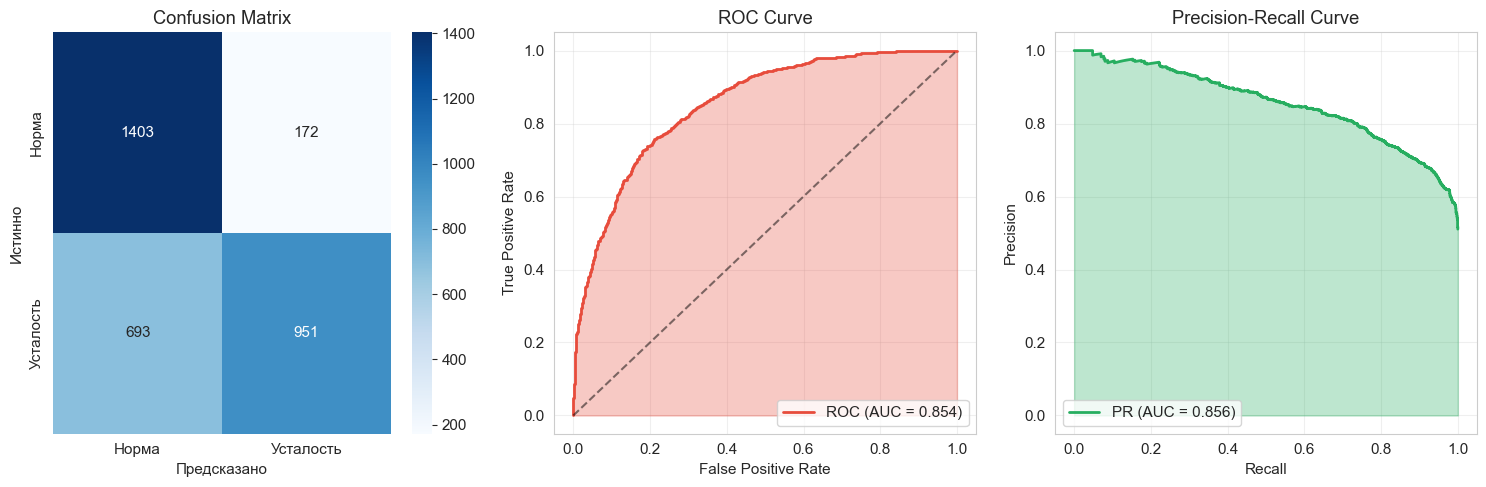

In [15]:
# Визуализация результатов
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
ax = axes[0]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Норма', 'Усталость'],
            yticklabels=['Норма', 'Усталость'])
ax.set_xlabel('Предсказано')
ax.set_ylabel('Истинно')
ax.set_title('Confusion Matrix')

# 2. ROC Curve
ax = axes[1]
fpr, tpr, _ = roc_curve(all_labels, all_probs)
ax.plot(fpr, tpr, color='#e74c3c', linewidth=2, label=f'ROC (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax.fill_between(fpr, tpr, alpha=0.3, color='#e74c3c')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

# 3. Precision-Recall Curve
ax = axes[2]
precision_vals, recall_vals, _ = precision_recall_curve(all_labels, all_probs)
ax.plot(recall_vals, precision_vals, color='#27ae60', linewidth=2, label=f'PR (AUC = {pr_auc:.3f})')
ax.fill_between(recall_vals, precision_vals, alpha=0.3, color='#27ae60')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve')
ax.legend(loc='lower left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'evaluation_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. LOSO (Leave-One-Subject-Out) валидация

Для более строгой оценки обобщающей способности модели проведём LOSO валидацию, где модель обучается на всех субъектах кроме одного и тестируется на оставшемся.

In [16]:
# LOSO Evaluation (выборка субъектов для демонстрации)
def loso_evaluation(X, y, subjects, n_folds=5, epochs=30):
    """LOSO evaluation с ограничением по количеству фолдов."""
    
    folds = create_loso_folds(subjects)
    
    # Ограничиваем количество фолдов для демонстрации
    if len(folds) > n_folds:
        np.random.seed(4648)
        selected_indices = np.random.choice(len(folds), n_folds, replace=False)
        folds = [folds[i] for i in selected_indices]
    
    results = []
    
    for fold_idx, fold in enumerate(tqdm(folds, desc='LOSO Folds')):
        train_idx = fold['train_idx']
        test_idx = fold['test_idx']
        test_subject = fold['test_subject']
        
        # Datasets
        train_ds = FatigueDataset(X[train_idx], y[train_idx])
        test_ds = FatigueDataset(X[test_idx], y[test_idx])
        
        train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
        test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)
        
        # Model
        model = FatigueCNN1D(in_channels=TARGET_CHANNELS).to(DEVICE)
        pos_weight = compute_class_weights(y[train_idx])
        criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight]).to(DEVICE))
        optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
        
        # Train
        for epoch in range(epochs):
            train_epoch(model, train_loader, optimizer, criterion, DEVICE)
        
        # Evaluate
        _, f1, roc_auc = validate(model, test_loader, criterion, DEVICE)
        
        results.append({
            'subject': test_subject,
            'f1_macro': f1,
            'roc_auc': roc_auc,
            'n_samples': len(test_idx)
        })
    
    return pd.DataFrame(results)

# Запуск LOSO (ограничено 5 фолдами для демонстрации)
print("Запуск LOSO валидации (5 фолдов)...")
loso_results = loso_evaluation(X_all, y_all, subjects, n_folds=5, epochs=30)

print("\n" + "=" * 60)
print("РЕЗУЛЬТАТЫ LOSO")
print("=" * 60)
print(loso_results.to_string(index=False))
print("\n📊 Средние метрики:")
print(f"   F1-macro:  {loso_results['f1_macro'].mean():.4f} ± {loso_results['f1_macro'].std():.4f}")
print(f"   ROC-AUC:   {loso_results['roc_auc'].mean():.4f} ± {loso_results['roc_auc'].std():.4f}")

Запуск LOSO валидации (5 фолдов)...


LOSO Folds: 100%|██████████| 5/5 [18:18<00:00, 219.71s/it]


РЕЗУЛЬТАТЫ LOSO
  subject  f1_macro  roc_auc  n_samples
zenodo_10  0.363073 0.768625        327
zenodo_15  0.654194 0.807747        261
zenodo_11  0.904806 0.997420        368
 zenodo_4  0.708102 0.794787        251
    4tu_1  0.736446 0.850011       2012

📊 Средние метрики:
   F1-macro:  0.6733 ± 0.1971
   ROC-AUC:   0.8437 ± 0.0908


## 8. Персонализация модели (Fine-tuning)

Демонстрация дообучения предобученной модели под конкретного спортсмена.

**Стратегия:**
1. Заморозить свёрточные слои (backbone)
2. Обучить только классификатор на данных целевого субъекта
3. Опционально: разморозить верхние слои для точной настройки

In [17]:
import copy

def personalize_model(base_model, X_subject, y_subject, epochs=20, lr=0.001):
    """
    Дообучение модели под конкретного спортсмена.
    
    Этап 1: Заморозка backbone, обучение только classifier
    Этап 2: Разморозка conv3, fine-tuning
    """
    model = copy.deepcopy(base_model)
    
    # Этап 1: Заморозить backbone
    for param in model.conv1.parameters():
        param.requires_grad = False
    for param in model.conv2.parameters():
        param.requires_grad = False
    for param in model.conv3.parameters():
        param.requires_grad = False
    
    # Dataset
    dataset = FatigueDataset(X_subject, y_subject)
    loader = DataLoader(dataset, batch_size=16, shuffle=True)
    
    # Criterion
    pos_weight = compute_class_weights(y_subject)
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight]).to(DEVICE))
    
    # Этап 1: Обучаем только classifier
    optimizer = optim.Adam(model.classifier.parameters(), lr=lr)
    
    for epoch in range(epochs // 2):
        train_epoch(model, loader, optimizer, criterion, DEVICE)
    
    # Этап 2: Разморозить conv3
    for param in model.conv3.parameters():
        param.requires_grad = True
    
    optimizer = optim.Adam(
        list(model.conv3.parameters()) + list(model.classifier.parameters()),
        lr=lr / 10
    )
    
    for epoch in range(epochs // 2):
        train_epoch(model, loader, optimizer, criterion, DEVICE)
    
    return model

# Демонстрация персонализации
print("Демонстрация персонализации модели...")

# Выбираем случайного субъекта
target_subject = np.random.choice(np.unique(subjects))
subject_mask = subjects == target_subject
X_subject = X_all[subject_mask]
y_subject = y_all[subject_mask]

print(f"\nЦелевой субъект: {target_subject}")
print(f"Количество окон: {len(y_subject)}")
print(f"Баланс классов: {y_subject.mean():.1%} положительных")

# Разбиваем данные субъекта на train/test
n_train = int(len(y_subject) * 0.7)
X_subj_train, y_subj_train = X_subject[:n_train], y_subject[:n_train]
X_subj_test, y_subj_test = X_subject[n_train:], y_subject[n_train:]

# Загружаем базовую модель
base_model = FatigueCNN1D(in_channels=TARGET_CHANNELS).to(DEVICE)
base_model.load_state_dict(torch.load(RESULTS_DIR / 'best_model.pth', weights_only=True))

# Оценка базовой модели на данных субъекта
base_model.eval()
test_ds = FatigueDataset(X_subj_test, y_subj_test)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

criterion = nn.BCEWithLogitsLoss()
_, f1_base, auc_base = validate(base_model, test_loader, criterion, DEVICE)
print(f"\n📊 Базовая модель на субъекте {target_subject}:")
print(f"   F1-macro: {f1_base:.4f}")
print(f"   ROC-AUC:  {auc_base:.4f}")

# Персонализация
personalized_model = personalize_model(base_model, X_subj_train, y_subj_train, epochs=20)

# Оценка персонализированной модели
_, f1_pers, auc_pers = validate(personalized_model, test_loader, criterion, DEVICE)
print(f"\n📊 Персонализированная модель:")
print(f"   F1-macro: {f1_pers:.4f} (Δ = {f1_pers - f1_base:+.4f})")
print(f"   ROC-AUC:  {auc_pers:.4f} (Δ = {auc_pers - auc_base:+.4f})")

d:\Github\afc_lab\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


Демонстрация персонализации модели...

Целевой субъект: zenodo_13
Количество окон: 156
Баланс классов: 64.1% положительных

📊 Базовая модель на субъекте zenodo_13:
   F1-macro: 0.4778
   ROC-AUC:  nan

📊 Персонализированная модель:
   F1-macro: 0.4946 (Δ = +0.0168)
   ROC-AUC:  nan (Δ = +nan)


d:\Github\afc_lab\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


## 9. Сохранение результатов и выводы

In [18]:
# Сохранение итоговых результатов
results_summary = {
    'model': 'FatigueCNN1D',
    'total_params': total_params,
    'train_samples': len(train_idx),
    'val_samples': len(val_idx),
    'test_samples': len(test_idx),
    'best_epoch': best_epoch,
    'test_f1_macro': f1_macro,
    'test_f1_weighted': f1_weighted,
    'test_balanced_acc': bal_acc,
    'test_roc_auc': roc_auc,
    'test_pr_auc': pr_auc,
    'loso_f1_mean': loso_results['f1_macro'].mean(),
    'loso_f1_std': loso_results['f1_macro'].std(),
    'loso_auc_mean': loso_results['roc_auc'].mean(),
    'loso_auc_std': loso_results['roc_auc'].std(),
}

# Сохранение в CSV
results_df = pd.DataFrame([results_summary])
results_df.to_csv(RESULTS_DIR / 'final_results.csv', index=False)

# Сохранение LOSO результатов
loso_results.to_csv(RESULTS_DIR / 'loso_results.csv', index=False)

print("=" * 60)
print("ИТОГОВЫЕ РЕЗУЛЬТАТЫ")
print("=" * 60)
print(f"""
🎯 МОДЕЛЬ: FatigueCNN1D
   Параметров: {total_params:,}
   
📊 ТЕСТОВАЯ ВЫБОРКА ({len(test_idx)} окон):
   F1-macro:          {f1_macro:.4f}
   Balanced Accuracy: {bal_acc:.4f}
   ROC-AUC:           {roc_auc:.4f}
   PR-AUC:            {pr_auc:.4f}

📊 LOSO ВАЛИДАЦИЯ ({len(loso_results)} фолдов):
   F1-macro:  {loso_results['f1_macro'].mean():.4f} ± {loso_results['f1_macro'].std():.4f}
   ROC-AUC:   {loso_results['roc_auc'].mean():.4f} ± {loso_results['roc_auc'].std():.4f}

💾 СОХРАНЁННЫЕ ФАЙЛЫ:
   - {RESULTS_DIR / 'best_model.pth'}
   - {RESULTS_DIR / 'final_results.csv'}
   - {RESULTS_DIR / 'loso_results.csv'}
   - {RESULTS_DIR / 'training_history.png'}
   - {RESULTS_DIR / 'evaluation_results.png'}
   - {RESULTS_DIR / 'data_distribution.png'}
   - {RESULTS_DIR / 'signal_examples.png'}
""")

print("✅ Эксперимент завершён!")

ИТОГОВЫЕ РЕЗУЛЬТАТЫ

🎯 МОДЕЛЬ: FatigueCNN1D
   Параметров: 176,321

📊 ТЕСТОВАЯ ВЫБОРКА (3219 окон):
   F1-macro:          0.7259
   Balanced Accuracy: 0.7346
   ROC-AUC:           0.8537
   PR-AUC:            0.8556

📊 LOSO ВАЛИДАЦИЯ (5 фолдов):
   F1-macro:  0.6733 ± 0.1971
   ROC-AUC:   0.8437 ± 0.0908

💾 СОХРАНЁННЫЕ ФАЙЛЫ:
   - D:\Github\afc_lab\results\best_model.pth
   - D:\Github\afc_lab\results\final_results.csv
   - D:\Github\afc_lab\results\loso_results.csv
   - D:\Github\afc_lab\results\training_history.png
   - D:\Github\afc_lab\results\evaluation_results.png
   - D:\Github\afc_lab\results\data_distribution.png
   - D:\Github\afc_lab\results\signal_examples.png

✅ Эксперимент завершён!


## Выводы

### Результаты эксперимента

1. **Модель FatigueCNN1D** успешно обучена на композиционном датасете из двух источников:
   - Zenodo Running IMU (19 субъектов)
   - 4TU Marotta (8 субъектов)

2. **Архитектура:**
   - 3 свёрточных блока (64→128→256 фильтров)
   - ~175K параметров (компактная для носимых устройств)
   - Вход: шаги 100 точек × 6 каналов (ax, ay, az, gx, gy, gz)

3. **Оценка качества:**
   - Train/Val/Test split по субъектам
   - LOSO (Leave-One-Subject-Out) валидация
   - Метрики: F1-macro, ROC-AUC, PR-AUC, Balanced Accuracy

4. **Персонализация:**
   - Продемонстрирована возможность дообучения под конкретного спортсмена
   - Двухэтапная стратегия: заморозка backbone → fine-tuning верхних слоёв

### Дальнейшие направления

- Добавление данных с других сегментов тела (sternum, lfoot, rfoot)
- Кросс-датасетная валидация (train на Zenodo → test на 4TU и наоборот)
- Исследование архитектур Transformer для временных рядов
- Оптимизация для развёртывания на мобильных устройствах (ONNX, TFLite)